In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("mymoviedb.csv",engine="python")

In [7]:
print(f"The dataset is having the {df.shape[0]} rows and the {df.shape[1]} columns")

The dataset is having the 9837 rows and the 9 columns


In [8]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


**Here,the datatype of the columns[Release_Date,Vote_Count,Vote_Average] is not correct**

In [11]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

**Here, there are some missing values**

In [253]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [255]:
df.duplicated().sum()

np.int64(0)

# Romoving the unwanted columns and Removing null value 

In [9]:
df.drop(["Overview","Poster_Url","Original_Language"],inplace=True,axis=1)

In [10]:
df.dropna(axis=0,inplace=True)

In [11]:
df.isnull().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

# Changing the columns datatype

In [12]:
df["Release_Date"]=pd.to_datetime(df["Release_Date"])

**here,we dont want the whole date we only want the release year**

In [13]:
df["Release_Date"]=df["Release_Date"].dt.year

In [14]:
df["Vote_Count"]=df["Vote_Count"].astype(int)

In [15]:
df["Vote_Average"]=df["Vote_Average"].astype(float)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9826 entries, 0 to 9836
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Release_Date  9826 non-null   int32  
 1   Title         9826 non-null   object 
 2   Popularity    9826 non-null   float64
 3   Vote_Count    9826 non-null   int64  
 4   Vote_Average  9826 non-null   float64
 5   Genre         9826 non-null   object 
dtypes: float64(2), int32(1), int64(1), object(2)
memory usage: 499.0+ KB


In [17]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


# Categorizing The Vote_Average column

**We would cut the Vote_Average columns valuye and make the 4 catatgory as [popular,average,below_avg,non_popular]**

In [18]:
def catagorizd_col(df,col,labels):
    edges=[df[col].describe()["min"],
           df[col].describe()["25%"],
           df[col].describe()["50%"],
           df[col].describe()["75%"],
           df[col].describe()["max"]]

    df[col]=pd.cut(df[col],edges,labels=labels,duplicates="drop")
    return df

In [19]:
labels=["not_popular","below_avg","average","popular"]
df=catagorizd_col(df,"Vote_Average",labels)

In [20]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


# Exploding the Genre

In [21]:
df["Genre"]=df["Genre"].str.split(", ")

In [22]:
df=df.explode("Genre").reset_index(drop=True)

In [23]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [24]:
df["Genre"].nunique()

19

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25792 entries, 0 to 25791
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25792 non-null  int32   
 1   Title         25792 non-null  object  
 2   Popularity    25792 non-null  float64 
 3   Vote_Count    25792 non-null  int64   
 4   Vote_Average  25551 non-null  category
 5   Genre         25792 non-null  object  
dtypes: category(1), float64(1), int32(1), int64(1), object(2)
memory usage: 932.3+ KB


# Data Visualization 

# 1] Distribition based on Genre

In [25]:
sns.set_theme(style="whitegrid")

In [26]:
total=df["Genre"].value_counts().sort_values(ascending=False)

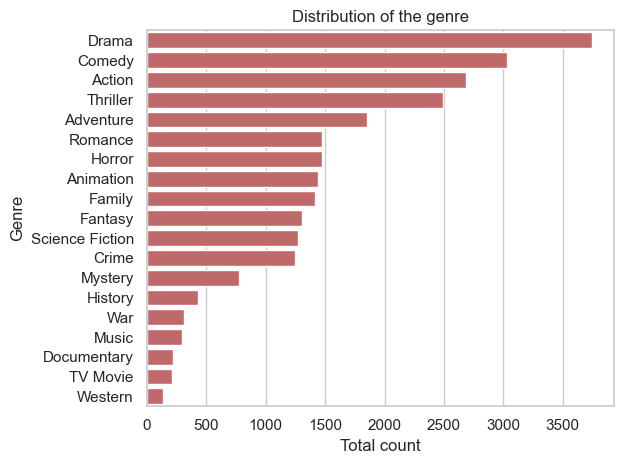

In [27]:
sns.barplot(y=total.index,x=total.values,color="indianred")
plt.title("Distribution of the genre")
plt.xlabel("Total count")
plt.ylabel("Genre")
plt.tight_layout()

plt.show()

**The most of the Films are from Genre Drama.**

# 2]Which genre has the highest votes ?

In [28]:
votes=df.groupby("Genre")["Vote_Count"].sum().sort_values(ascending=False)
votes

Genre
Drama              5141495
Action             4868675
Adventure          4313869
Comedy             3933497
Thriller           3631594
Science Fiction    2850476
Fantasy            2521940
Family             2046625
Crime              1980261
Romance            1803756
Animation          1525010
Horror             1448486
Mystery            1181275
History             527056
War                 448918
Music               297446
Western             186860
TV Movie             68441
Documentary          38224
Name: Vote_Count, dtype: int64

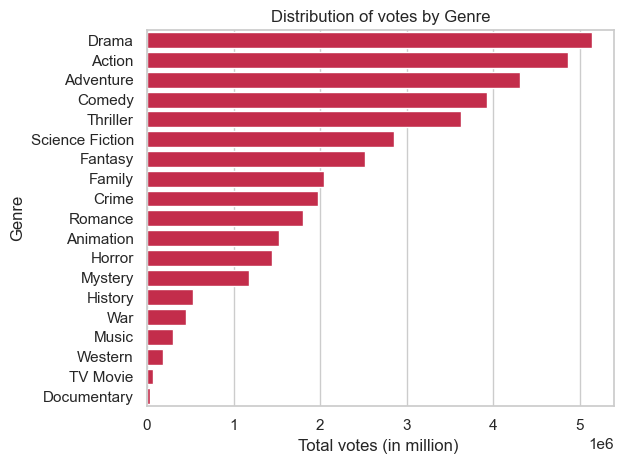

In [29]:
sns.barplot(y=votes.index,x=votes.values,color='crimson')
plt.title('Distribution of votes by Genre') 
plt.xlabel("Total votes (in million) ")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

**The genre-Drama gets the highes votes.**

# 3]which movie got highest popularity and what is its genre?

In [30]:
df[df["Popularity"]==df["Popularity"].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


**The movie "Spider-Man: No Way Home" has the highest Popularity**

# 4]which movie got lowest popularity and what is its genre?

In [31]:
df[df["Popularity"]==df["Popularity"].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25786,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25787,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152,average,History
25789,1984,Threads,13.354,186,popular,War
25790,1984,Threads,13.354,186,popular,Drama
25791,1984,Threads,13.354,186,popular,Science Fiction


**The movie "The United States vs. Billie Holiday" has the lowest Popularity**

# 5]Which year leads to highest movie release

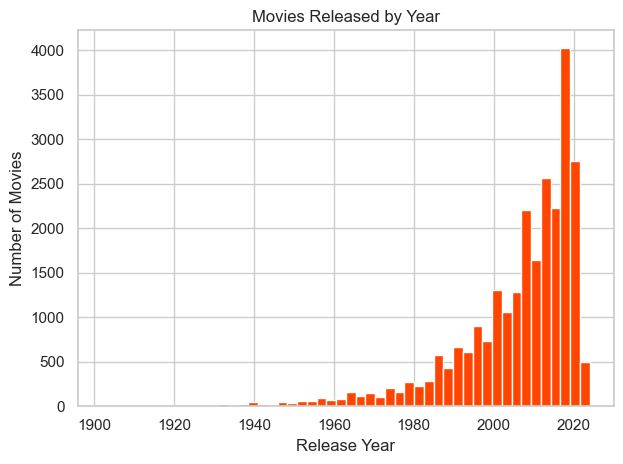

In [67]:

plt.hist(df["Release_Date"],bins=50,color="orangered")
plt.title("Movies Released by Year(histogram)")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()


In [89]:
year_count = df["Release_Date"].value_counts().sort_values(ascending=False)

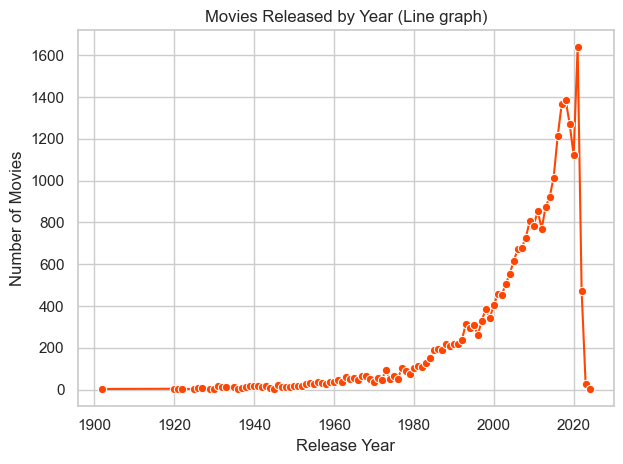

In [90]:
sns.lineplot(x=year_count.index,y=year_count.values,marker="o",color="orangered")
plt.title("Movies Released by Year (Line graph)")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()